<a href="https://colab.research.google.com/github/offjisung-alt/MachineLearning/blob/main/5_%ED%8A%B8%EB%A6%AC%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 결정 트리 (Decision Tree)

결정 트리(Decision Tree)는 데이터를 여러 기준으로 나누어 분류하거나 예측하는 머신러닝 알고리즘이다.

트리(Tree) 구조를 사용하기 때문에 사람이 이해하기 쉽고 해석이 가능하다는 장점이 있다.

---

# 1. 결정 트리의 구조

결정 트리는 다음과 같은 구조를 가진다.

```text
루트 노드 (Root Node)
        ↓
내부 노드 (Internal Node)
        ↓
잎 노드 (Leaf Node)
```

---

## 예시

과일을 분류한다고 가정하자.

```text
색깔이 빨간색인가?
          ↓
      예      아니오
      ↓          ↓
   사과      크기가 큰가?
                 ↓
              예     아니오
              ↓         ↓
            수박      바나나
```

---

# 2. 결정 트리 학습 과정

결정 트리는 데이터를 계속 분할하면서 학습한다.

```text
전체 데이터
↓
가장 좋은 기준 선택
↓
데이터 분할
↓
각 노드에서 반복
↓
최종 분류
```

---

## 목표

각 노드에 가능한 한

```text
같은 클래스끼리 모이도록
```

데이터를 나누는 것이다.

즉,

```text
순수한(Pure) 노드
```

를 만드는 것이 목표이다.

---

# 불순도 (Impurity)

## 정의

불순도는

```text
한 노드 안에
얼마나 다양한 클래스가 섞여 있는가
```

를 나타내는 지표이다.

---

## 예시 1

```text
사과 10개
```

만 있다면

```text
100% 동일 클래스
```

이다.

불순도는 0이다.

---

## 예시 2

```text
사과 5개
바나나 5개
```

라면

```text
클래스가 섞여 있음
```

불순도가 높다.

---

# 지니 지수 (Gini Index)

가장 많이 사용하는 불순도 지표이다.

---

## 공식

$$
Gini
=
1-\sum_{i=1}^{K}p_i^2
$$

---

여기서

- $K$ : 클래스 개수
- $p_i$ : 클래스 i의 비율

이다.

---

# 지니 지수 예제

사과 5개

바나나 5개

라고 하자.

총 10개이므로

$$
p_1=\frac{5}{10}=0.5
$$

$$
p_2=\frac{5}{10}=0.5
$$

---

공식에 대입하면

$$
Gini
=
1-(0.5^2+0.5^2)
$$

$$
=
1-(0.25+0.25)
$$

$$
=
0.5
$$

---

## 완전히 순수한 경우

사과 10개

$$
p=1
$$

---

$$
Gini
=
1-1^2
=
0
$$

---

즉

```text
지니 지수 = 0
```

이면 가장 순수한 상태이다.

---

# 엔트로피 (Entropy)

정보 이론에서 사용하는 불순도 측정 방법이다.

---

## 공식

$$
Entropy
=
-\sum_{i=1}^{K}
p_i\log_2(p_i)
$$

---

# 엔트로피 예제

사과 5개

바나나 5개

---

$$
Entropy
=
-(0.5\log_2(0.5)+0.5\log_2(0.5))
$$

---

$$
=
-(0.5(-1)+0.5(-1))
$$

---

$$
=
1
$$

---

## 완전히 순수한 경우

$$
Entropy
=
-(1\times\log_2(1))
=
0
$$

---

즉

```text
엔트로피 = 0
```

이면 가장 순수한 상태이다.

---

# 지니 지수와 엔트로피 비교

| 구분 | 지니 지수 | 엔트로피 |
|--------|--------|--------|
| 공식 | $1-\sum p_i^2$ | $-\sum p_i\log_2p_i$ |
| 계산 속도 | 빠름 | 느림 |
| 사용 알고리즘 | CART | ID3, C4.5 |
| 순수한 노드 | 0 | 0 |

---

## Scikit-Learn

Scikit-Learn의 DecisionTreeClassifier는 기본적으로

```python
criterion='gini'
```

를 사용한다.

---

# 정보 이득 (Information Gain)

결정 트리는

```text
어떤 특성으로 분할할 것인가?
```

를 결정해야 한다.

---

이를 위해 사용하는 기준이

```text
정보 이득
```

이다.

---

# 정보 이득의 개념

분할 전보다

```text
얼마나 불순도가 감소했는가
```

를 의미한다.

---

## 공식

$$
Information\ Gain
=
I(Parent)
-
\sum_j
\frac{N_j}{N}
I(Child_j)
$$

---

여기서

- $I$ : 불순도
- $N$ : 부모 노드 데이터 수
- $N_j$ : 자식 노드 데이터 수

이다.

---

# 정보 이득 예제

분할 전

```text
사과 5
바나나 5
```

지니 지수

$$
0.5
$$

---

분할 후

왼쪽 노드

```text
사과 5
```

지니

$$
0
$$

---

오른쪽 노드

```text
바나나 5
```

지니

$$
0
$$

---

정보 이득

$$
0.5
-
\left(
\frac{5}{10}\times0
+
\frac{5}{10}\times0
\right)
$$

$$
=
0.5
$$

---

정보 이득이 클수록 좋은 분할이다.

---

# 가지치기 (Pruning)

결정 트리는 계속 분할하면 모든 데이터를 완벽하게 맞출 수 있다.

하지만

```text
과적합
```

이 발생한다.

---

## 과적합 예시

```text
훈련 정확도 100%
테스트 정확도 70%
```

---

이를 방지하기 위해 가지치기를 사용한다.

---

# 가지치기의 개념

필요 없는 가지를 제거하여

```text
더 단순한 트리
```

를 만드는 과정이다.

---

## 효과

- 과적합 감소
- 일반화 성능 향상
- 해석 쉬움

---

# 정지 규칙 (Stopping Rule)

트리가 무한히 성장하지 않도록 멈추는 규칙이다.

---

## max_depth

트리 최대 깊이 제한

```python
DecisionTreeClassifier(
    max_depth=3
)
```

---

## min_samples_split

노드를 분할하기 위한 최소 샘플 수

```python
DecisionTreeClassifier(
    min_samples_split=10
)
```

---

## min_samples_leaf

리프 노드가 가져야 하는 최소 샘플 수

```python
DecisionTreeClassifier(
    min_samples_leaf=5
)
```

---

## 정보 이득이 거의 없음

분할해도 불순도 감소가 거의 없으면 중단한다.

---

# 특성 중요도 (Feature Importance)

결정 트리는

```text
어떤 특성이
예측에 가장 중요한가?
```

를 계산할 수 있다.

---

## 개념

특성이 불순도를 얼마나 감소시켰는지 측정한다.

---

예시

```text
나이
성별
소득
키
```

가 있을 때

```text
소득 : 0.50
나이 : 0.30
성별 : 0.15
키 : 0.05
```

라고 나올 수 있다.

---

## 특성 중요도 공식

특성 $j$의 중요도는

$$
FI_j
=
\sum
(\text{불순도 감소량})
\times
(\text{노드 샘플 비율})
$$

로 계산된다.

---

# Scikit-Learn에서 확인

```python
tree.feature_importances_
```

---

예시

```python
array([0.55, 0.25, 0.15, 0.05])
```

---

## 의미

```text
첫 번째 특성 : 55%
두 번째 특성 : 25%
세 번째 특성 : 15%
네 번째 특성 : 5%
```

의 중요도를 가진다는 뜻이다.

---

# 결정 트리 학습 전체 과정

```text
전체 데이터
↓
불순도 계산
↓
정보 이득 계산
↓
가장 좋은 특성 선택
↓
데이터 분할
↓
반복
↓
정지 규칙 만족
↓
리프 노드 생성
↓
필요 시 가지치기
```

---

# 핵심 정리

1. 결정 트리는 데이터를 반복적으로 분할하는 알고리즘이다.

2. 불순도는 클래스가 얼마나 섞여 있는지를 의미한다.

3. 지니 지수 공식

$$
Gini
=
1-\sum p_i^2
$$

4. 엔트로피 공식

$$
Entropy
=
-\sum p_i\log_2(p_i)
$$

5. 정보 이득은 분할 전후의 불순도 감소량이다.

$$
Information\ Gain
=
I(Parent)
-
\sum_j
\frac{N_j}{N}
I(Child_j)
$$

6. 가지치기는 과적합을 방지하기 위해 트리를 단순하게 만드는 과정이다.

7. 정지 규칙은 트리의 성장을 제한한다.

8. 특성 중요도는 각 특성이 불순도 감소에 기여한 정도를 의미한다.

9. Scikit-Learn은 기본적으로 지니 지수를 사용한다.

10. 결정 트리는 해석이 쉽고 특성 중요도를 제공한다는 장점이 있다.

In [1]:
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')

In [2]:
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [4]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [5]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [6]:
# 훈련 데이터와 테스트 데이터로 나누기
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

print(train_input.shape, test_input.shape)

(5197, 3) (1300, 3)


In [7]:
# 데이터 정규화
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [8]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


In [9]:
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


#결정 트리

In [10]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.996921300750433
0.8523076923076923


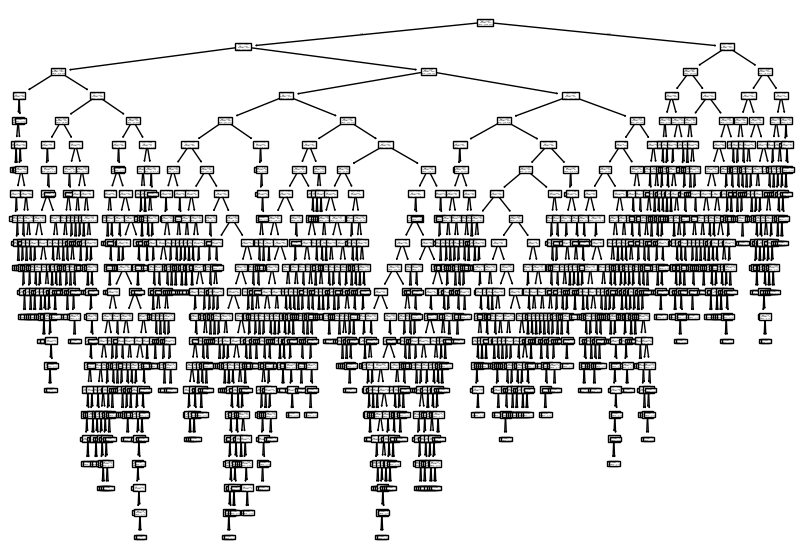

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 7))
plot_tree(dt)
plt.show()

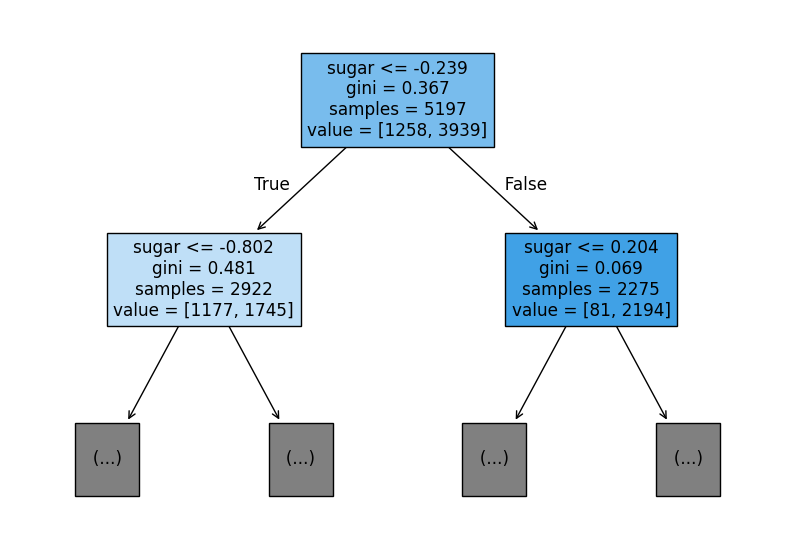

In [12]:
plt.figure(figsize=(10, 7))
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

0.8454877814123533
0.8415384615384616


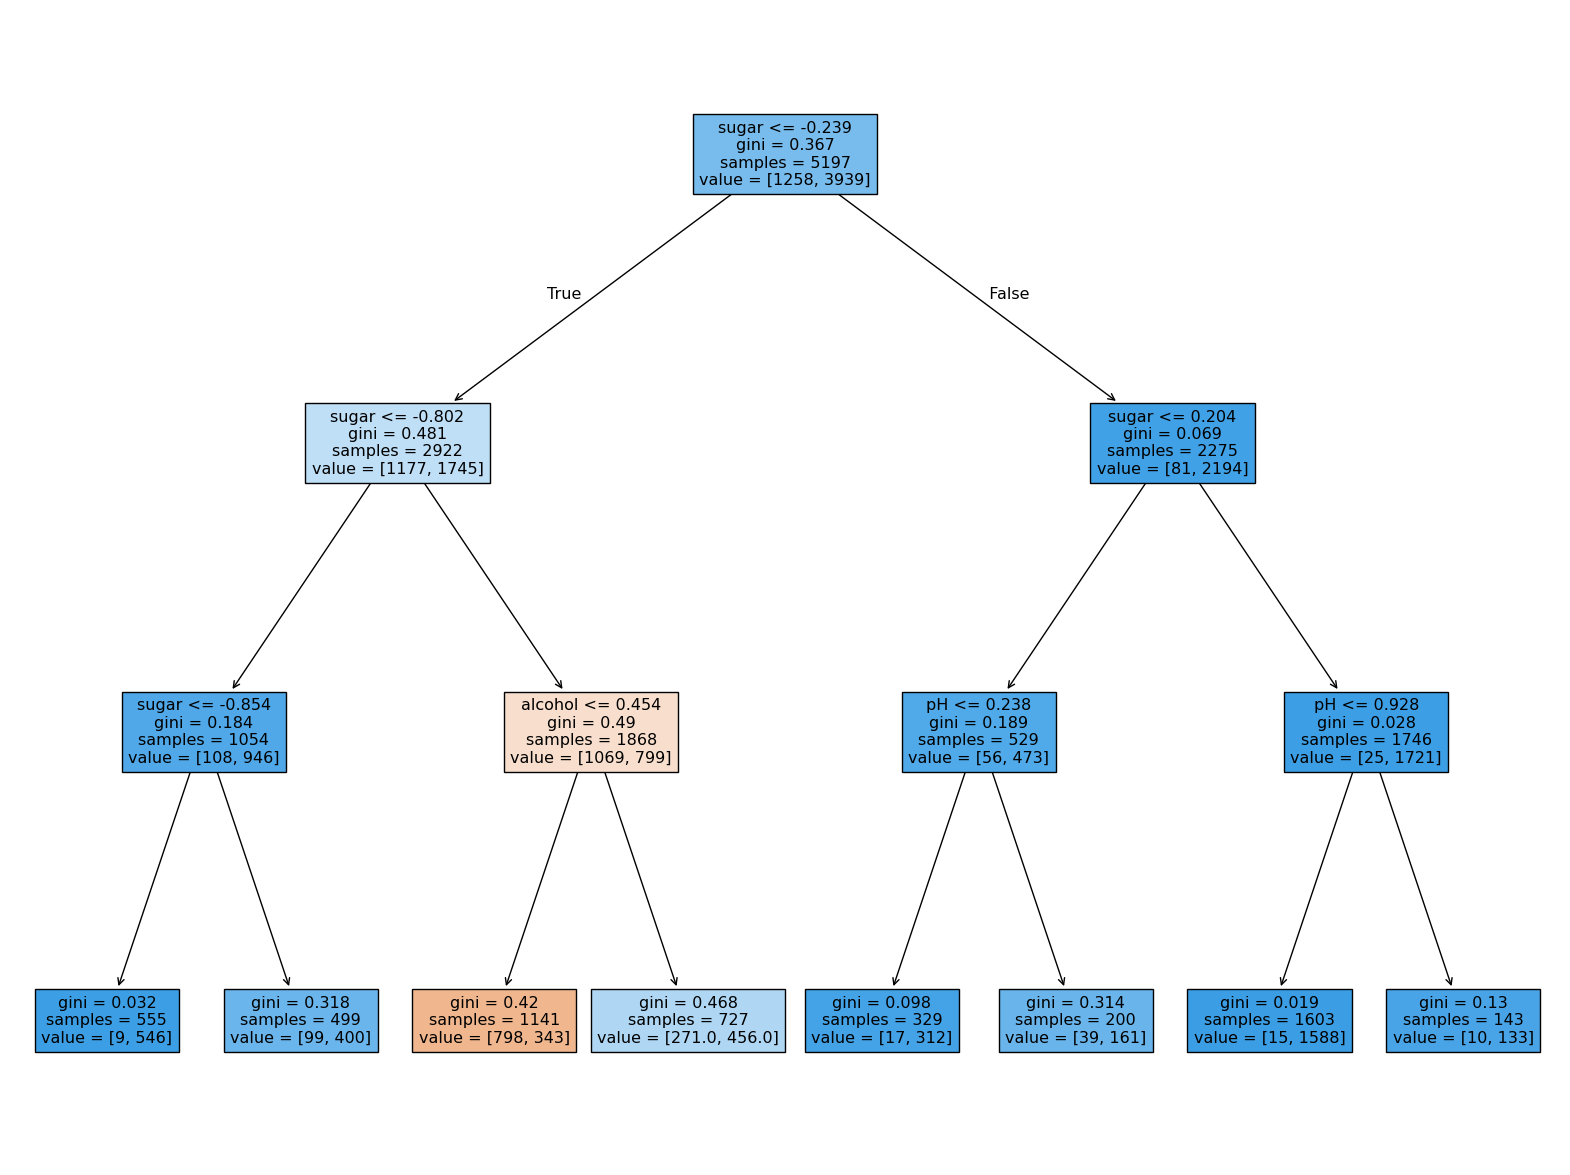

In [13]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [14]:
# 의사결정 트리의 경우 스케일의 영향을 받지 않는ㄷ. 즉 데이터 전처리를 할 필요가 없다
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))


0.8454877814123533
0.8415384615384616


In [15]:
# 어떤 특성이 가장 유용한지 나타내주는 특성 중요도를 계산해준다.
print(dt.feature_importances_)

[0.12345626 0.86862934 0.0079144 ]


# 검증 세트 (Validation Set)

머신러닝에서는 모델을 학습한 후 성능을 평가해야 한다.

데이터를 다음과 같이 나눈다.

```text
전체 데이터
↓
훈련 세트 (Train Set)
테스트 세트 (Test Set)
```

---

하지만 테스트 세트를 계속 사용하여 모델을 수정하면 문제가 발생한다.

```text
테스트 세트에 과적합
```

될 수 있기 때문이다.

---

이를 해결하기 위해

```text
훈련 세트
검증 세트
테스트 세트
```

로 데이터를 나눈다.

---

# 데이터 분할

보통 다음과 같이 나눈다.

```text
Train : 60%
Validation : 20%
Test : 20%
```

또는

```text
Train : 70%
Validation : 15%
Test : 15%
```

---

# 역할

## 훈련 세트 (Training Set)

모델 학습

```text
가중치 학습
```

---

## 검증 세트 (Validation Set)

모델 선택

```text
하이퍼파라미터 선택
```

---

## 테스트 세트 (Test Set)

최종 평가

```text
실제 성능 확인
```

---

# 예시

```python
train_input
val_input
test_input
```

---

학습 과정

```text
Train Set
↓
모델 학습
↓
Validation Set
↓
성능 평가
↓
최적 하이퍼파라미터 선택
↓
최종 Test Set 평가
```

---

# 교차 검증 (Cross Validation)

## 등장 배경

데이터가 적은 경우

검증 세트를 따로 떼어 놓으면

```text
학습 데이터 감소
```

문제가 발생한다.

---

예를 들어

```text
100개 데이터
```

에서

```text
Train 80
Validation 20
```

으로 나누면

학습에 사용할 수 있는 데이터가 줄어든다.

---

이를 해결하기 위해 사용하는 방법이

```text
교차 검증
```

이다.

---

# K-Fold Cross Validation

가장 많이 사용하는 교차 검증 방법이다.

---

## K=5 예시

전체 데이터를

```text
Fold1
Fold2
Fold3
Fold4
Fold5
```

로 나눈다.

---

### 1번째 학습

```text
Train : Fold2~Fold5
Validation : Fold1
```

---

### 2번째 학습

```text
Train : Fold1,3,4,5
Validation : Fold2
```

---

### 3번째 학습

```text
Train : Fold1,2,4,5
Validation : Fold3
```

---

### 4번째 학습

```text
Train : Fold1,2,3,5
Validation : Fold4
```

---

### 5번째 학습

```text
Train : Fold1,2,3,4
Validation : Fold5
```

---

# 최종 성능

5개의 검증 점수를 평균낸다.

$$
CV
=
\frac{Score_1+Score_2+Score_3+Score_4+Score_5}{5}
$$

---

# 장점

## 1. 데이터 활용 극대화

모든 데이터가

```text
학습
+
검증
```

에 사용된다.

---

## 2. 평가가 안정적

특정 검증 세트에 의존하지 않는다.

---

# Scikit-Learn 예시

```python
from sklearn.model_selection import cross_validate

scores = cross_validate(
    model,
    train_input,
    train_target,
    cv=5
)
```

---

# Stratified K-Fold

분류 문제에서는

각 클래스 비율을 유지해야 한다.

---

예시

```text
고양이 80%
개 20%
```

---

Fold를 만들 때도

```text
고양이 80%
개 20%
```

비율을 유지한다.

---

Scikit-Learn의 분류 모델은 기본적으로

```python
StratifiedKFold
```

를 사용한다.

---

# 하이퍼파라미터 (Hyperparameter)

## 정의

학습 전에 사람이 직접 설정하는 값

---

예시

```python
max_depth=3
n_neighbors=5
learning_rate=0.01
batch_size=64
```

---

## 문제

어떤 값이 좋은지 모른다.

---

따라서

```text
하이퍼파라미터 최적화
```

가 필요하다.

---

# 그리드 서치 (Grid Search)

## 개념

가능한 모든 조합을 전부 시도하는 방법

---

예시

```python
param_grid = {
    'max_depth':[3,5,7],
    'min_samples_split':[2,4,6]
}
```

---

가능한 조합

```text
(3,2)
(3,4)
(3,6)

(5,2)
(5,4)
(5,6)

(7,2)
(7,4)
(7,6)
```

---

총

$$
3 \times 3
=
9
$$

개의 조합을 모두 탐색한다.

---

# GridSearchCV

Scikit-Learn에서 사용하는 클래스

```python
from sklearn.model_selection import GridSearchCV
```

---

예시

```python
gs = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)
```

---

동작 과정

```text
모든 파라미터 조합 생성
↓
각 조합마다 교차 검증 수행
↓
평균 성능 계산
↓
최고 성능 선택
```

---

# 장점

모든 조합을 탐색하므로

```text
최적값을 놓칠 가능성이 적음
```

---

# 단점

조합 수가 많아지면

```text
시간이 매우 오래 걸림
```

---

예시

```python
3 × 4 × 5 × 6
```

개의 후보가 있으면

$$
360
$$

개의 조합을 평가해야 한다.

---

# 랜덤 서치 (Random Search)

## 등장 배경

Grid Search는 너무 느릴 수 있다.

---

예시

```python
learning_rate
batch_size
dropout
weight_decay
```

등이 있으면

조합 수가 폭발적으로 증가한다.

---

# 개념

모든 조합을 탐색하지 않는다.

---

대신

```text
무작위(Random)
```

로 일부 조합만 선택한다.

---

예시

```python
param_dist = {
    'max_depth': range(1,100),
    'min_samples_split': range(2,100)
}
```

---

Grid Search

```text
99 × 98
=
9702개
```

---

Random Search

```text
100개만 랜덤 선택
```

---

# RandomizedSearchCV

Scikit-Learn 클래스

```python
from sklearn.model_selection import RandomizedSearchCV
```

---

예시

```python
rs = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=100,
    cv=5
)
```

---

여기서

```python
n_iter=100
```

은

```text
100번 랜덤 추출
```

을 의미한다.

---

# 장점

## 1. 매우 빠름

모든 조합을 확인하지 않는다.

---

## 2. 고차원 탐색에 유리

하이퍼파라미터가 많을수록 유리하다.

---

## 3. 좋은 성능

실제로 Grid Search와 비슷한 결과를 얻는 경우가 많다.

---

# 단점

운이 나쁘면

```text
최적 조합을 못 찾을 수도 있음
```

---

# Grid Search vs Random Search

| 항목 | Grid Search | Random Search |
|--------|--------|--------|
| 탐색 방식 | 모든 조합 | 무작위 조합 |
| 속도 | 느림 | 빠름 |
| 최적해 발견 | 높음 | 확률적 |
| 파라미터 수 적음 | 유리 | 보통 |
| 파라미터 수 많음 | 불리 | 유리 |

---

# 전체 흐름

```text
Train Set
↓
교차 검증
↓
Grid Search 또는 Random Search
↓
최적 하이퍼파라미터 선택
↓
최종 모델 학습
↓
Test Set 평가
```

---

# 핵심 정리

1. 검증 세트는 하이퍼파라미터를 선택하기 위해 사용한다.

2. 테스트 세트는 최종 성능 평가에만 사용한다.

3. 교차 검증은 데이터를 여러 번 나누어 검증하는 방법이다.

4. K-Fold 교차 검증은 데이터를 K개로 나누어 번갈아 검증한다.

5. 교차 검증 점수는 다음과 같이 계산한다.

$$
CV
=
\frac{1}{K}
\sum_{i=1}^{K}
Score_i
$$

6. Grid Search는 모든 하이퍼파라미터 조합을 탐색한다.

7. Random Search는 일부 조합만 무작위로 탐색한다.

8. 파라미터가 많을수록 Random Search가 효율적이다.

9. Scikit-Learn에서는 GridSearchCV와 RandomizedSearchCV를 사용한다.

10. 실제 머신러닝에서는 교차 검증 + 하이퍼파라미터 탐색을 함께 사용하는 경우가 많다.

In [16]:
import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [17]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

sub_input, val_input, sub_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)
print(sub_input.shape, val_input.shape)

(4157, 3) (1040, 3)


In [18]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)
print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

0.9971133028626413
0.864423076923077


In [19]:
# k-폴드 교차검증
from sklearn.model_selection import cross_validate
scores = cross_validate(dt, train_input, train_target)
print(scores)

{'fit_time': array([0.01359105, 0.01213312, 0.0185101 , 0.0133121 , 0.01474071]), 'score_time': array([0.0019083 , 0.00266719, 0.00238562, 0.00170398, 0.00165462]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [20]:
import numpy as np
print(np.mean(scores['test_score']))

0.855300214703487


In [21]:
from sklearn.model_selection import StratifiedKFold
scores = cross_validate(dt, train_input, train_target, cv=StratifiedKFold())
print(np.mean(scores['test_score']))

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(dt, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))

0.855300214703487
0.8574181117533719


In [22]:
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease':[0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

In [23]:
gs = GridSearchCV(DecisionTreeClassifier(random_state=24), params, n_jobs=-1)
gs.fit(train_input, train_target)
dt = gs.best_estimator_
print(dt.score(train_input, train_target))

0.8934000384837406


In [24]:
print(gs.best_params_)
print(gs.cv_results_['mean_test_score'])

best_index = np.argmax(gs.cv_results_['mean_test_score'])
print(gs.cv_results_['params'][best_index])

{'min_impurity_decrease': 0.0004}
[0.86761531 0.86665285 0.86530762 0.86838584 0.86761605]
{'min_impurity_decrease': 0.0004}


In [25]:
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth': range(5, 20, 1),
          'min_samples_split': range(2, 100, 10)}

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(train_input, train_target)

print(gs.best_params_)

{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}


In [26]:
print(np.max(gs.cv_results_['mean_test_score']))

0.8683865773302731


In [27]:
# 랜덤 서치
from scipy.stats import uniform, randint
rgen = randint(0, 10)
rgen.rvs(10)

array([4, 2, 4, 5, 3, 3, 6, 5, 8, 6])

In [28]:
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 99, 110, 105,  82, 115,  89, 116,  93,  92,  99]))

In [29]:
ugen = uniform(0,1)
ugen.rvs(10)

array([0.17827639, 0.2406137 , 0.56405867, 0.53558348, 0.53572934,
       0.44447145, 0.89361123, 0.55974636, 0.61423907, 0.44890376])

In [30]:
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25),}

In [31]:
from sklearn.model_selection import RandomizedSearchCV
gs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params, n_iter=100, n_jobs=-1, random_state=42)
gs.fit(train_input, train_target)

RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ec91b551580>,
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ec92bfc2120>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ec91c1dfb30>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ec91ba94d10>},
                   random_state=42)

In [32]:
print(gs.best_params_)

{'max_depth': 39, 'min_impurity_decrease': np.float64(0.00034102546602601173), 'min_samples_leaf': 7, 'min_samples_split': 13}


In [33]:
print(np.max(gs.cv_results_['mean_test_score']))

0.8695428296438884


In [34]:
dt = gs.best_estimator_
print(dt.score(test_input, test_target))

0.86


#트리의 앙상블

# 정형 데이터(Structured Data)와 비정형 데이터(Unstructured Data)

## 정형 데이터 (Structured Data)

정형 데이터는 미리 정해진 형식과 구조를 가진 데이터이다.

주로 행(Row)과 열(Column) 형태의 테이블 구조로 저장되며, 데이터베이스(DB)에서 쉽게 관리할 수 있다.

### 예시

| 이름 | 나이 | 성별 |
|------|------|------|
| 김철수 | 25 | 남 |
| 이영희 | 22 | 여 |

### 특징

- 데이터 구조가 명확하다.
- SQL을 이용하여 쉽게 조회할 수 있다.
- 머신러닝 모델에 바로 사용할 수 있다.
- 데이터 전처리가 비교적 쉽다.

### 활용 예시

- 고객 정보
- 매출 데이터
- 금융 거래 기록
- 센서 데이터

---

## 비정형 데이터 (Unstructured Data)

비정형 데이터는 정해진 구조가 없는 데이터이다.

컴퓨터가 바로 이해하기 어렵기 때문에 추가적인 전처리가 필요하다.

### 예시

- 텍스트
- 이미지
- 음성
- 영상

### 특징

- 데이터 구조가 일정하지 않다.
- 데이터의 양이 매우 크다.
- 전처리 과정이 복잡하다.
- 딥러닝 분야에서 많이 활용된다.

### 활용 예시

- SNS 게시글
- 유튜브 영상
- 의료 영상
- 음성 녹음 파일

---

# 앙상블 학습 (Ensemble Learning)

## 개념

앙상블 학습은 여러 개의 머신러닝 모델을 결합하여 하나의 강력한 모델을 만드는 방법이다.

사람들이 함께 의사결정을 하면 실수가 줄어드는 것처럼 여러 모델의 예측 결과를 종합하여 성능을 향상시킨다.

## 장점

- 예측 성능 향상
- 과적합 감소
- 일반화 성능 향상
- 안정적인 결과 제공

## 대표적인 앙상블 방법

1. 배깅(Bagging)
2. 부스팅(Boosting)
3. 스태킹(Stacking)

---

# 랜덤 포레스트 (Random Forest)

## 개념

랜덤 포레스트는 여러 개의 결정 트리(Decision Tree)를 생성한 뒤 결과를 종합하여 최종 예측을 수행하는 앙상블 알고리즘이다.

"숲(Forest)"이라는 이름은 많은 나무(Tree)를 모아놓았다는 의미이다.

## 동작 과정

### 1단계

원본 데이터에서 여러 개의 부트스트랩 샘플 생성

### 2단계

각 샘플로 결정 트리 생성

### 3단계

각 트리가 독립적으로 예측 수행

### 4단계

결과를 종합하여 최종 예측

- 분류 문제 → 다수결 투표(Voting)
- 회귀 문제 → 평균값(Averaging)

## 주요 하이퍼파라미터

### n_estimators

생성할 트리의 개수

```python
RandomForestClassifier(n_estimators=100)
```

### max_depth

트리의 최대 깊이

```python
RandomForestClassifier(max_depth=10)
```

### max_features

분할 시 사용할 특성 개수

```python
RandomForestClassifier(max_features='sqrt')
```

## 장점

- 높은 정확도
- 과적합 감소
- 특성 중요도 제공
- 병렬 처리 가능

## 단점

- 학습 시간이 길다.
- 메모리 사용량이 크다.
- 해석이 어렵다.

---

# 부트스트랩 샘플 (Bootstrap Sample)

## 개념

원본 데이터에서 중복을 허용하여 무작위로 샘플을 추출하는 방법이다.

랜덤 포레스트의 핵심 기술이다.

## 예시

원본 데이터

```text
[A, B, C, D, E]
```

부트스트랩 샘플

```text
[A, B, B, D, E]
```

또는

```text
[C, C, A, E, D]
```

처럼 같은 데이터가 여러 번 뽑힐 수 있다.

## 목적

각 트리가 서로 다른 데이터를 학습하게 하여 다양성을 높인다.

이를 통해 앙상블 효과가 발생한다.

---

# 엑스트라 트리 (Extra Trees)

## 개념

Extra Trees(Extremely Randomized Trees)는 랜덤 포레스트보다 더 큰 무작위성을 사용하는 앙상블 기법이다.

랜덤 포레스트와 비슷하지만 분할 기준을 더 랜덤하게 선택한다.

---

## 랜덤 포레스트와 비교

### 랜덤 포레스트

1. 특성 랜덤 선택
2. 최적의 분할 위치 탐색

### 엑스트라 트리

1. 특성 랜덤 선택
2. 분할 위치도 랜덤 선택

---

## 장점

- 학습 속도가 빠름
- 과적합 감소
- 높은 일반화 성능

## 단점

- 데이터에 따라 정확도가 약간 낮을 수 있음

---

# 그래디언트 부스팅 (Gradient Boosting)

## 개념

여러 개의 약한 학습기(Weak Learner)를 순차적으로 학습시키는 부스팅 기법이다.

이전 모델이 틀린 부분을 다음 모델이 학습하면서 점점 성능을 향상시킨다.

---

## 동작 과정

### 첫 번째 트리 생성

```text
예측 수행
```

### 오차 계산

```text
실제값 - 예측값
```

### 두 번째 트리 생성

```text
오차를 학습
```

### 반복

```text
오차를 계속 수정
```

---

## 주요 하이퍼파라미터

### learning_rate

각 트리가 수정하는 정도

```python
GradientBoostingClassifier(
    learning_rate=0.1
)
```

### n_estimators

트리 개수

```python
GradientBoostingClassifier(
    n_estimators=100
)
```

### max_depth

트리 깊이

```python
GradientBoostingClassifier(
    max_depth=3
)
```

---

## 장점

- 매우 높은 성능
- 다양한 데이터에 적용 가능
- 특성 중요도 제공

## 단점

- 학습 속도가 느림
- 하이퍼파라미터 튜닝 필요

---

# 히스토그램 기반 그래디언트 부스팅 (Histogram-based Gradient Boosting)

## 개념

그래디언트 부스팅의 속도를 개선한 알고리즘이다.

데이터를 구간(Bin)으로 나누어 계산량을 크게 줄인다.

Scikit-Learn에서는 다음 클래스로 제공된다.

```python
HistGradientBoostingClassifier
```

---

## 기존 Gradient Boosting

```text
모든 데이터를 사용하여
최적의 분할점 탐색
```

계산량이 많다.

---

## Histogram Gradient Boosting

```text
데이터를 여러 구간으로 나눈 뒤
구간 단위로 계산
```

계산량이 매우 감소한다.

---

## 예시

원본 데이터

```text
72
73
74
75
76
77
78
79
```

히스토그램 구간

```text
70~74
75~79
```

처럼 묶어서 처리한다.

---

## 장점

- 매우 빠른 학습 속도
- 적은 메모리 사용
- 대용량 데이터에 적합
- 최신 부스팅 알고리즘의 기반

---

## 대표적인 구현체

### Scikit-Learn

```python
HistGradientBoostingClassifier
```

### XGBoost

```python
XGBoost
```

### LightGBM

```python
LightGBM
```

### CatBoost

```python
CatBoost
```

---

# 핵심 요약

| 알고리즘 | 핵심 아이디어 |
|----------|-------------|
| 랜덤 포레스트 | 여러 트리를 독립적으로 학습 후 투표 |
| 부트스트랩 샘플 | 중복 허용 랜덤 샘플링 |
| 엑스트라 트리 | 분할 위치까지 랜덤 선택 |
| 그래디언트 부스팅 | 이전 모델의 오차를 계속 수정 |
| 히스토그램 기반 그래디언트 부스팅 | 데이터를 구간화하여 속도 향상 |
| 앙상블 학습 | 여러 모델을 결합하여 성능 향상 |

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
wine = pd.read_csv('https://bit.ly/wine_csv_data')
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

In [37]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9973541965122431 0.8905151032797809


In [38]:
rf.fit(train_input, train_target)
print(rf.feature_importances_)

[0.23167441 0.50039841 0.26792718]


In [39]:
# 부트스트랩 샘플에 포함되지 않고 남는 샘플들을 이용하여 훈련한 결과를 평가하는 것
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
rf.fit(train_input, train_target)
print(rf.oob_score_)

0.8934000384837406


In [40]:
# ExtraTreesClassifier
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9974503966084433 0.8887848893166506


In [41]:
et.fit(train_input, train_target)
print(et.feature_importances_)

[0.20183568 0.52242907 0.27573525]


In [42]:
# Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8881086892152563 0.8720430147331015


In [43]:
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9464595437171814 0.8780082549788999


In [44]:
gb.fit(train_input, train_target)
print(gb.feature_importances_)

[0.15887763 0.6799705  0.16115187]


In [45]:
# 히스토그램 기반 그레디언트 부스팅
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target, return_train_score=True)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


0.9321723946453317 0.8801241948619236


In [46]:
# 특성 중요도를 계산하기 위한 permutation_importance()
# n_repeats 매개변수는 랜덤하게 섞을 횟수 지정

from sklearn.inspection import permutation_importance
hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.08876275 0.23438522 0.08027708]


In [47]:
result = permutation_importance(hgb, test_input, test_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.05969231 0.20238462 0.049     ]


In [48]:
hgb.score(test_input, test_target)

0.8723076923076923

In [49]:
# XGBoost: 그래디언트 부스팅 알고리즘 구현 라이브러리

from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9567059184812372 0.8783915747390243


In [51]:
# LightGBM
from lightgbm import LGBMClassifier
lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.935828414851749 0.8801251203079884
